# LAB 05.02 - Model evaluation

In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/fagonzalezo/ai4eng-unal/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()

In [ ]:
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L05.02", varname="student");

## Task 1: Partition randomly `numpy` arrays

observe we can select specific rows and/or columns on a numpy array

In [3]:
import numpy as np

x = np.random.randint(100, size=(20,5))
x[:,0] = range(len(x))
x[0,:] = range(x.shape[1])
x

array([[ 0,  1,  2,  3,  4],
       [ 1, 82, 23, 30, 89],
       [ 2, 81, 97,  0, 67],
       [ 3, 28,  2, 22, 93],
       [ 4, 56,  4, 22, 29],
       [ 5, 55, 12, 12, 55],
       [ 6, 55, 30, 99, 92],
       [ 7, 68, 61, 27,  5],
       [ 8,  0, 28, 93, 75],
       [ 9, 31, 53, 68, 63],
       [10, 94,  1, 69, 79],
       [11, 68, 82, 17, 25],
       [12, 47, 98, 80, 79],
       [13,  0, 59, 97,  9],
       [14, 10, 70, 17, 56],
       [15, 97, 84,  6, 94],
       [16, 73, 97, 10, 79],
       [17, 74, 20, 26, 92],
       [18, 68, 76, 23, 92],
       [19, 25, 25, 54, 81]])

In [4]:
ridxs = np.r_[2,4,5]
x[ridxs]

array([[ 2, 81, 97,  0, 67],
       [ 4, 56,  4, 22, 29],
       [ 5, 55, 12, 12, 55]])

In [5]:
cidxs = np.r_[1,3]
x[:,cidxs]

array([[ 1,  3],
       [82, 30],
       [81,  0],
       [28, 22],
       [56, 22],
       [55, 12],
       [55, 99],
       [68, 27],
       [ 0, 93],
       [31, 68],
       [94, 69],
       [68, 17],
       [47, 80],
       [ 0, 97],
       [10, 17],
       [97,  6],
       [73, 10],
       [74, 26],
       [68, 23],
       [25, 54]])

In [6]:
x[ridxs][:, cidxs]

array([[81,  0],
       [56, 22],
       [55, 12]])

and the dimensions of the array are accessible through `len` and `shape`

In [7]:
len(x), x.shape

(20, (20, 5))

observe also how we can partition it

In [8]:
x[:3]

array([[ 0,  1,  2,  3,  4],
       [ 1, 82, 23, 30, 89],
       [ 2, 81, 97,  0, 67]])

In [9]:
x[3:]

array([[ 3, 28,  2, 22, 93],
       [ 4, 56,  4, 22, 29],
       [ 5, 55, 12, 12, 55],
       [ 6, 55, 30, 99, 92],
       [ 7, 68, 61, 27,  5],
       [ 8,  0, 28, 93, 75],
       [ 9, 31, 53, 68, 63],
       [10, 94,  1, 69, 79],
       [11, 68, 82, 17, 25],
       [12, 47, 98, 80, 79],
       [13,  0, 59, 97,  9],
       [14, 10, 70, 17, 56],
       [15, 97, 84,  6, 94],
       [16, 73, 97, 10, 79],
       [17, 74, 20, 26, 92],
       [18, 68, 76, 23, 92],
       [19, 25, 25, 54, 81]])

we can do the same thing with vectors

In [10]:
v = np.arange(100,120)
v

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119])

In [11]:
v[:5], v[5:]

(array([100, 101, 102, 103, 104]),
 array([105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 119]))

finally, observe how we can create a random permutation of a specific vector

In [12]:
np.random.permutation(v)

array([104, 110, 100, 106, 117, 113, 119, 115, 105, 114, 118, 116, 107,
       102, 103, 101, 109, 112, 111, 108])

or the first natural numbers

In [13]:
p = np.random.permutation(20)
p

array([ 5, 15, 17, 18,  7,  1, 12, 11,  2, 13,  9,  3, 19,  8,  0, 14, 16,
        6, 10,  4])

how do you interpret this?

In [14]:
v[p[5:]]

array([101, 112, 111, 102, 113, 109, 103, 119, 108, 100, 114, 116, 106,
       110, 104])

In [15]:
x[p[:5]]

array([[ 5, 55, 12, 12, 55],
       [15, 97, 84,  6, 94],
       [17, 74, 20, 26, 92],
       [18, 68, 76, 23, 92],
       [ 7, 68, 61, 27,  5]])

### assignment

in this task you will have to complete the function  `split_data` below so that:

- it accepts two arguments `X` and `y`, either of which can be any numpy array (1D, 2D, etc.) of the **same** size $n$ (observe the  `assert` statement), and a `pct` 
- creates a random permutation of the natural number from $0$ to $n-1$
- partitions the permutations so that the first partition contains the first `n1_elements` $=$ `int(n * pct)` numbers, and the second partition the rest
- interpret the permutation partitions components as indexes to `X` and `y` so that they are partitioned into `X1`, `X2` and `y1`, `y2` respectively

note that **indexes to array** must be of type `int`. do the following to convert a float to int

In [16]:
a,b = 10,.3
c = a*b
print (c)
c = int(c)
print(c)

3.0
3


In [17]:
def split_data(X, y, pct):
    
    assert len(X)==len(y), "X and y must have the same length"
    assert pct>0 and pct<1, "pct must be in the (0,1) iterval"
    
    permutation = np.random.permutation(len(X))
    n1_elements = int(len(X) * pct)
    permutation_partition_1 = permutation[:n1_elements]
    permutation_partition_2 = permutation[n1_elements:]
    X1 = X[permutation_partition_1]
    X2 = X[permutation_partition_2]
    y1 = y[permutation_partition_1]
    y2 = y[permutation_partition_2]
    return X1, X2, y1, y2

check your solution manually with the following code

In [18]:
XX = np.random.randint(100, size=(20,8))
yy = np.arange(100,100+len(XX))
XX[:,0] = range(len(XX))
XX[0,:] = range(XX.shape[1])
print (XX)
print (yy)

[[ 0  1  2  3  4  5  6  7]
 [ 1 77 23 33 36 91 23  9]
 [ 2 52 59 26 93 63 61  4]
 [ 3 99 77 74 86 66 35 55]
 [ 4 55 70 98 67 52 57 54]
 [ 5 57 98 89 77 70 42 53]
 [ 6 80 49  6 38 30 99 70]
 [ 7 94 81 60 42 31 58 65]
 [ 8 17 38 55 26 40 32 64]
 [ 9  3 56 45 72 37 33  8]
 [10 56 66 97 59 36 29 17]
 [11  3 79 96 87 48 78  8]
 [12 97 68 88 72 94 42  0]
 [13 67 35 25 96 24 67 41]
 [14 10 24 88 38 41 12 66]
 [15 81 11 78 65 38 80 84]
 [16 30 47 57 51 42 76 29]
 [17 72 41 84 20 54  6 79]
 [18 94  8  7 51 37 26 94]
 [19 56 20 67 45 20 60 36]]
[100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119]


In [19]:
Xtr, Xts, ytr, yts = split_data(XX, yy, pct=.7)

In [20]:
# check partition ok
np.sum(XX), np.sum(Xtr) + np.sum(Xts), np.sum(yy), np.sum(ytr)+np.sum(yts)

(7228, 7228, 2190, 2190)

In [21]:
print (Xtr, "\n--")
print (Xts, "\n--")
print (ytr, "\n--")
print (yts, "\n--")

[[13 67 35 25 96 24 67 41]
 [ 3 99 77 74 86 66 35 55]
 [ 4 55 70 98 67 52 57 54]
 [19 56 20 67 45 20 60 36]
 [ 6 80 49  6 38 30 99 70]
 [ 7 94 81 60 42 31 58 65]
 [ 9  3 56 45 72 37 33  8]
 [15 81 11 78 65 38 80 84]
 [17 72 41 84 20 54  6 79]
 [ 2 52 59 26 93 63 61  4]
 [12 97 68 88 72 94 42  0]
 [10 56 66 97 59 36 29 17]
 [16 30 47 57 51 42 76 29]
 [ 1 77 23 33 36 91 23  9]] 
--
[[11  3 79 96 87 48 78  8]
 [ 0  1  2  3  4  5  6  7]
 [ 8 17 38 55 26 40 32 64]
 [18 94  8  7 51 37 26 94]
 [ 5 57 98 89 77 70 42 53]
 [14 10 24 88 38 41 12 66]] 
--
[113 103 104 119 106 107 109 115 117 102 112 110 116 101] 
--
[111 100 108 118 105 114] 
--


In [22]:
Xts

array([[11,  3, 79, 96, 87, 48, 78,  8],
       [ 0,  1,  2,  3,  4,  5,  6,  7],
       [ 8, 17, 38, 55, 26, 40, 32, 64],
       [18, 94,  8,  7, 51, 37, 26, 94],
       [ 5, 57, 98, 89, 77, 70, 42, 53],
       [14, 10, 24, 88, 38, 41, 12, 66]])

**submit your code**

In [23]:
student.submit_task(globals(), task_id="task_01");

## Task 2: Fit a model and make predictions

observe how we create new data from synthetic datasets available in `sklearn`

In [24]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from local.lib import mlutils
%matplotlib inline

In [25]:
X, y = make_moons(200, noise=0.2)
X.shape, y.shape

((200, 2), (200,))

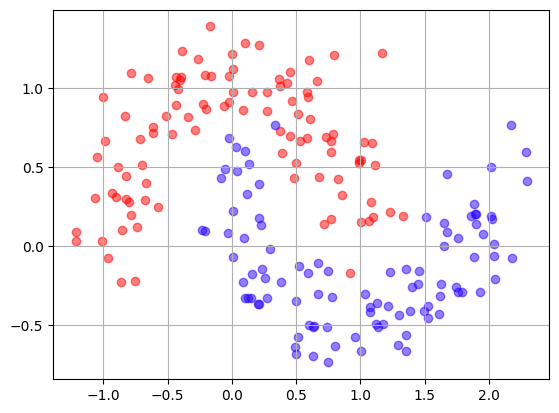

In [26]:
mlutils.plot_2Ddata(X,y); plt.grid();

observe also how we create an algorithm instance and fit a model

(0.513025, 0.486975)

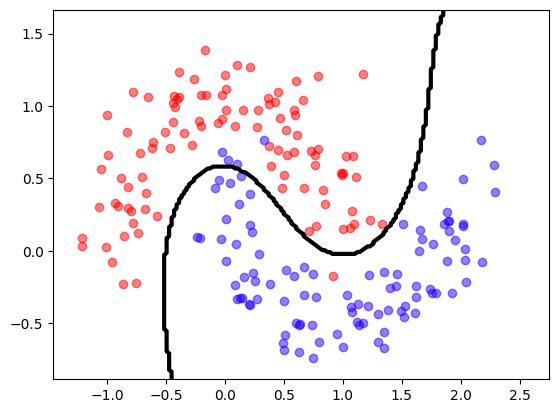

In [27]:
from sklearn.svm import SVC
estimator = SVC(gamma=1)
estimator.fit(X,y)
mlutils.plot_2Ddata_with_boundary(estimator.predict, X, y)

and how we make predictions

In [28]:
preds = estimator.predict(X)
print (preds.shape)
preds

(200,)


array([1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0])

in this task you have to complete the following function so that:

- it makes two non-random partitions of `X` and `y`. One containing the first half of the data and one containing the second part. If the number of elements of `X` is odd, then the second half will contain one more element than the first half.
- it fits the model with the first part of the data
- it makes predictions on the second half of the data
- returns the estimator fitted, and the predictions on the second half of the data.

In [29]:
def fit_and_predict(estimator, X, y):
    assert len(X)==len(y), "X and y must have the same length"
    n = len(X) // 2
    estimator.fit(X[:n], y[:n])
    predictions = estimator.predict(X[n:])
    return estimator, predictions

check your code. your predictions should be similar to

    preds
    >> array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0])

In [30]:
X = np.array([[ 0.74799424, -0.5867667 ],
       [-0.64457753,  1.25127894],
       [ 0.53682593,  0.10931563],
       [-0.88825294, -0.06987509],
       [ 0.99612638, -0.52295157],
       [ 1.20586692,  0.01930477],
       [-0.19368482,  0.65121567],
       [ 0.1973759 ,  0.82250723],
       [ 0.94859234, -0.5457241 ],
       [ 1.87967948, -0.22740261],
       [ 0.58766146,  0.3982837 ],
       [ 0.27731571,  1.14369568],
       [-0.67421956,  0.12785382],
       [ 0.56957459,  1.05330376],
       [ 1.52435938, -0.29864338],
       [-0.15973608,  0.21790711],
       [ 1.59037406, -0.56875485],
       [ 0.43257507, -0.48900315],
       [ 1.09440413, -0.73789029],
       [-0.32940869,  0.74671384]])
y = np.array([1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0])
X.shape, y.shape

((20, 2), (20,))

In [31]:
from sklearn.linear_model import LogisticRegression
estimator = LogisticRegression()
estimator, preds = fit_and_predict(estimator, X, y)
preds

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0])

**submit your code**

In [32]:
student.submit_task(globals(), task_id="task_02");

## Task 3: Select data with indices

Observe how we can create a vector or matrix of `True/False` (boolean) by applying a condition to any matrix or vector

In [33]:
import numpy as np
y = np.random.randint(10, size=15)
print (y)

[4 4 2 6 7 0 6 3 9 3 9 3 2 9 7]


In [34]:
y_less_than_5 = y<5
print (y_less_than_5)

[ True  True  True False False  True False  True False  True False  True
  True False False]


and how we can select elements of a vector using a boolean vector of the same length

In [35]:
y[y_less_than_5]

array([4, 4, 2, 0, 3, 3, 3, 2])

In [36]:
y[y<5]

array([4, 4, 2, 0, 3, 3, 3, 2])

python doesn't really care how you construct the vector of booleans to index any other vector or array

In [37]:
v = np.random.randint(20, size=15)
v

array([ 1,  1,  2,  2,  1,  7, 18, 10,  2, 16, 13,  0, 14,  7, 17])

In [38]:
v[y<5]

array([ 1,  1,  2,  7, 10, 16,  0, 14])

in this task you will complete the function `select_per_class` such that:

- receives an array of data `X` and a vector of labels `y`, of the same length
- the labels `y` are binary, they can only have values `0` or `1`
- makes two partitions of `X`, one corresponding to the places where y is 0, and another where y is 1
- returns the two partitions

For instance, for the following X and y

    X = np.array([[8, 8, 5, 2, 0, 0],
                  [4, 4, 8, 1, 3, 7],
                  [4, 5, 3, 6, 9, 6],
                  [0, 3, 5, 3, 5, 3],
                  [0, 7, 2, 7, 1, 7],
                  [5, 7, 7, 1, 8, 5],
                  [2, 5, 7, 3, 8, 0],
                  [7, 2, 5, 9, 8, 7],
                  [1, 6, 6, 1, 6, 0],
                  [0, 7, 6, 5, 3, 4]])

    y = np.array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

your function must return the following two matrices:

    [[8 8 5 2 0 0]
     [4 4 8 1 3 7]
     [4 5 3 6 9 6]
     [0 3 5 3 5 3]
     [2 5 7 3 8 0]
     [7 2 5 9 8 7]]
     
    [[0 7 2 7 1 7]
     [5 7 7 1 8 5]
     [1 6 6 1 6 0]
     [0 7 6 5 3 4]]


In [39]:
def select_per_class(X, y):
    X1 = X[y==0]
    X2 = X[y==1]
    return X1, X2

check manually your code

In [40]:
X = np.array([[8, 8, 5, 2, 0, 0],
              [4, 4, 8, 1, 3, 7],
              [4, 5, 3, 6, 9, 6],
              [0, 3, 5, 3, 5, 3],
              [0, 7, 2, 7, 1, 7],
              [5, 7, 7, 1, 8, 5],
              [2, 5, 7, 3, 8, 0],
              [7, 2, 5, 9, 8, 7],
              [1, 6, 6, 1, 6, 0],
              [0, 7, 6, 5, 3, 4]])

y = np.array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

In [41]:
a,b = select_per_class(X, y)
print (a)
print (b)

[[8 8 5 2 0 0]
 [4 4 8 1 3 7]
 [4 5 3 6 9 6]
 [0 3 5 3 5 3]
 [2 5 7 3 8 0]
 [7 2 5 9 8 7]]
[[0 7 2 7 1 7]
 [5 7 7 1 8 5]
 [1 6 6 1 6 0]
 [0 7 6 5 3 4]]


**submit your code**

In [42]:
student.submit_task(globals(), task_id="task_03");

## Task 4: Measure accuracy

complete the following function such that:

- it receives to binary vectors (composed of 0's and 1's) of the same length
- returns the percentage of elements that are the same in both vectors

recall that

- if `a` and `b` are vectors of the same length a==b   returns a vector of booleans in which positions in True signal that elements in those position are the same
- if `k` is a vector of booleans, `sum(k)` returns the number of `True` elements.


for the following two vectors you should get 0.375

    a = np.array([1,0,0,0,1,1,0,0])
    b = np.array([1,1,1,1,0,1,0,1])
    accuracy(a, b)
    >>> 0.375


In [43]:
def accuracy(y_true, y_pred):
    result = np.mean(y_true == y_pred)
    return result

In [44]:
a = np.array([1,0,0,0,1,1,0,0])
b = np.array([1,1,1,1,0,1,0,1])
accuracy(a,b)

0.375

**submit your code**

In [45]:
student.submit_task(globals(), task_id="task_04");

## Task 5: Random split, fit and predict

complete the following function so that:

- fits the estimator with a random sample of size `train_pct` of the data `X` and binary labels `y`. You can use the `split_data` function developed previously
- makes predictions on the test part of the data
- measures accuracy of those predictions. you may use the function created previously
- returns the estimator fitted, the test part of `X` and `y`, and the accuracy measured


the execution below should return something with the following structure (the actual numbers will change)


    (LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                        intercept_scaling=1, l1_ratio=None, max_iter=100,
                        multi_class='warn', n_jobs=None, penalty='l2',
                        random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                        warm_start=False), array([[-0.76329684,  0.2572069 ],
            [ 1.02356829,  0.37629873],
            [ 0.32099415,  0.82244488],
            [ 1.08858315, -0.61299904],
            [ 0.58470767,  0.58510559],
            [ 1.60827644, -0.15477173],
            [ 1.53121784,  0.78121504],
            [-0.42734156,  0.87585237],
            [-0.36368682,  0.72152586],
            [ 1.05312619,  0.19835526]]), array([0, 0, 1, 1, 0, 1, 1, 0, 0, 0]), 0.6)

In [46]:

def split_fit_predict(estimator, X, y, train_pct):
    
    def split_data(X, y, pct):
        assert len(X)==len(y), "X and y must have the same length"
        assert pct>0 and pct<1, "pct must be in the (0,1) iterval"
        
        permutation = np.random.permutation(len(X))
        n1_elements = int(len(X) * pct)
        permutation_partition_1 = permutation[:n1_elements]
        permutation_partition_2 = permutation[n1_elements:]
        X1 = X[permutation_partition_1]
        X2 = X[permutation_partition_2]
        y1 = y[permutation_partition_1]
        y2 = y[permutation_partition_2]
        return X1, X2, y1, y2
    
    def accuracy(y_true, y_pred):
        result = np.mean(y_true == y_pred)
        return result

    Xtr, Xts, ytr, yts = split_data(X, y, train_pct)
    estimator.fit(Xtr, ytr)
    preds_ts = estimator.predict(Xts)
    return estimator, Xts, yts, accuracy(yts, preds_ts)

In [47]:
from sklearn.linear_model import LogisticRegression

X, y = make_moons(100, noise=0.2)
estimator = LogisticRegression(solver="lbfgs")
split_fit_predict(estimator, X, y, train_pct=0.9)

(LogisticRegression(),
 array([[ 0.47354187,  0.1760096 ],
        [ 0.75550216, -0.12453087],
        [ 0.80538753,  0.70411751],
        [ 0.10854632,  0.2122957 ],
        [ 0.31367023,  0.90956609],
        [ 1.10789125, -0.14238062],
        [-0.78223007,  0.90663   ],
        [ 1.25410643, -0.18082227],
        [ 0.94558402,  0.68263655],
        [ 0.90277163,  1.17556573]]),
 array([1, 1, 0, 1, 0, 0, 0, 0, 0, 0]),
 0.7)

**submit your code**

In [48]:
student.submit_task(globals(), task_id="task_05");